# Build a missing-data hatch overlay for ERA5 drought over Africa

This notebook downloads monthly ERA5 drought data from the Copernicus Climate Data Store using `cdsapi`, extracts the NetCDF file, identifies the Africa-only pixels where the drought product is missing, converts that mask into a crossed-hatch raster pattern, previews it, and saves it as a separate NetCDF overlay layer for ADAGUC.

Before running it, make sure your CDS credentials are configured in `~/.cdsapirc`.

In [1]:
from importlib import reload
from pathlib import Path

import cdsapi
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import geopandas as gpd
import regionmask
from shapely.ops import unary_union

import c3s_atlas.customized_regions as cr
from c3s_atlas.utils import extract_zip_and_delete


/home/abdessamadelh/miniconda3/envs/atlas-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Resolve project paths

This makes the notebook work whether Jupyter was started from the repository root or from a subdirectory.

In [2]:
repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "c3s_atlas").exists() and (path / "auxiliar").exists()
)

dest = repo_root / "book" / "customizing" / "data" / "africa_era5_drought"
dest.mkdir(parents=True, exist_ok=True)

repo_root, dest


(PosixPath('/home/abdessamadelh/Documents/stage/Tests/c3s-atlas-main'),
 PosixPath('/home/abdessamadelh/Documents/stage/Tests/c3s-atlas-main/book/customizing/data/africa_era5_drought'))

## Download ERA5 from CDS

The request uses the `multi-origin-c3s-atlas` dataset already used in this repository. The geographical subset is a broad Africa bounding box, and the precise continent mask is applied afterward. This version switches to a drought indicator (SPEI-6) and uses a slightly more detailed Natural Earth boundary layer for a cleaner continental mask.

In [3]:
c = cdsapi.Client()

request_variable = "monthly_standardised_precipitation_evapotranspiration_index_for_6_months_cumulation_period"

# This drought setup uses the SPEI-6 variable already referenced elsewhere
# in this repository for Copernicus Atlas downloads.
zip_path = dest / "spei6_ERA5_Africa.zip"
dataset = "multi-origin-c3s-atlas"
request = {
    "origin": "era5",
    "domain": "global",
    "period": "1940-2024",
    "variable": request_variable,
    "bias_adjustment": "no_bias_adjustment",
    "area": [38, -20, -36, 55],
}

if not list(dest.glob("*.nc")):
    c.retrieve(dataset, request).download(zip_path)
    extract_zip_and_delete(zip_path)
    print("Download and extraction complete.")
else:
    print(f"NetCDF already present in {dest}")


NetCDF already present in /home/abdessamadelh/Documents/stage/Tests/c3s-atlas-main/book/customizing/data/africa_era5_drought


## Open the downloaded NetCDF

In [4]:
nc_files = sorted(
    path for path in dest.glob("*.nc")
    if path.name not in {"era5_africa_drought_masked.nc", "era5_africa_drought_missing_mask.nc", "era5_africa_drought_missing_hatch.nc"}
)
if not nc_files:
    raise FileNotFoundError(f"No NetCDF file found in {dest}")

nc_path = nc_files[0]
ds = xr.open_dataset(nc_path)

print("Opened:", nc_path.name)
print("Dimensions:", ds.dims)
print("Data variables:", list(ds.data_vars))
ds


Opened: spei6_ERA5_Africa.nc
Dimensions: FrozenMappingWarningOnValuesAccess({'lat': 297, 'bnds': 2, 'lon': 301, 'time': 1020})
Data variables: ['lat_bnds', 'lon_bnds', 'time_bnds', 'spei6', 'crs']


<xarray.Dataset> Size: 365MB
Dimensions:    (lat: 297, bnds: 2, lon: 301, time: 1020)
Coordinates:
  * lat        (lat) float64 2kB -36.0 -35.75 -35.5 -35.25 ... 37.5 37.75 38.0
  * lon        (lon) float64 2kB -20.0 -19.75 -19.5 -19.25 ... 54.5 54.75 55.0
  * time       (time) datetime64[ns] 8kB 1940-01-01 1940-02-01 ... 2024-12-01
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (lat, bnds) float64 5kB ...
    lon_bnds   (lon, bnds) float64 5kB ...
    time_bnds  (time, bnds) datetime64[ns] 16kB ...
    spei6      (time, lat, lon) float32 365MB ...
    crs        int32 4B ...
Attributes: (12/26)
    Conventions:                CF-1.9 ACDD-1.3
    title:                      Copernicus Interactive Climate Atlas: gridded...
    summary:                    Monthly/annual gridded data from observations...
    institution:                Copernicus Climate Change Service (C3S)
    producers:                  Institute of Physics of Cantabria (IFCA, CSIC...
    license:                    CC-BY 4.0, https://creativecommons.org/licens...
    ...                         ...
    geospatial_lon_max:         179.875
    geospatial_lon_resolution:  0.25
    geospatial_lon_units:       degrees_east
    date_created:               2025-03-31 17:20:58.422650+02:00
    tracking_id:                214fe8d1-e29d-48fd-afaf-e7260d2d3c80
    project_id:                 c3s-cica-atlas

## Build a precise Africa mask and derive a crossed-hatch overlay layer

This avoids the incomplete local Africa GeoJSON and uses a finer-resolution Natural Earth country boundary layer directly. The output overlay keeps only African pixels where the drought dataset is missing and draws a crossed-hatch pattern over them.

In [5]:
reload(cr)

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip"
)
africa_gdf = world[world["CONTINENT"] == "Africa"].copy()

# Fix possible geometry issues before dissolving into one continent polygon.
africa_gdf["geometry"] = africa_gdf.geometry.buffer(0)
africa_shape = unary_union(africa_gdf.geometry)

africa_region = regionmask.Regions(
    [africa_shape],
    names=["Africa"],
    abbrevs=["AFR"],
    name="Africa continent",
)

mask = africa_region.mask(ds["lon"], ds["lat"])
inside_africa = mask == 0

preferred_vars = ["spei6", "spi6", "spei", "drought", "monthly_standardised_precipitation_evapotranspiration_index_for_6_months_cumulation_period"]
var_name = next((name for name in preferred_vars if name in ds.data_vars), None)

if var_name is None:
    candidates = [
        name for name, da in ds.data_vars.items()
        if {"lat", "lon"}.issubset(da.dims) and "bnds" not in da.dims
    ]
    if not candidates:
        raise ValueError("No drought variable with lat/lon dimensions was found.")
    var_name = candidates[0]

da = ds[var_name]
time_dims = [dim for dim in ("time", "valid_time") if dim in da.dims]
missing_all_time = da.isnull().all(time_dims[0]) if time_dims else da.isnull()
missing_in_africa = xr.where(inside_africa & missing_all_time, 1.0, np.nan).astype("float32")
lat_size = missing_in_africa.sizes["lat"]
lon_size = missing_in_africa.sizes["lon"]
row_idx = xr.DataArray(np.arange(lat_size), dims=("lat",), coords={"lat": missing_in_africa["lat"]})
col_idx = xr.DataArray(np.arange(lon_size), dims=("lon",), coords={"lon": missing_in_africa["lon"]})

# Crossed hatch: keep one diagonal every few pixels in both directions.
spacing = 6
thickness = 1
diag_a = ((row_idx + col_idx) % spacing) <= thickness
diag_b = (np.abs(row_idx - col_idx) % spacing) <= thickness
hatch_pattern = diag_a | diag_b

hatch_name = f"{var_name}_missing_hatch"
hatch_da = xr.where(inside_africa & missing_all_time & hatch_pattern, 1.0, np.nan).astype("float32")
hatch_da = hatch_da.rename(hatch_name)
hatch_da.attrs = {
    "long_name": f"Crossed-hatch overlay for missing {var_name} pixels over Africa",
    "comment": "Value 1 marks hatch pixels inside African areas where the drought product is missing for all timesteps.",
    "units": "1",
}

ds_hatch = hatch_da.to_dataset()
if "crs" in ds:
    ds_hatch["crs"] = ds["crs"]

ds_hatch = cr.crop_to_bbox(ds_hatch, lon_bounds=(-18.0, 52.0), lat_bounds=(-35.0, 37.5))
hatch_da = ds_hatch[hatch_name]

print("African entities used:", len(africa_gdf))
print("Sample names:", africa_gdf["NAME"].head().tolist())
print("Source variable:", var_name)
print("Overlay dimensions:", ds_hatch.dims)
print("Overlay variables:", list(ds_hatch.data_vars))
ds_hatch


African entities used: 54
Sample names: ['Zimbabwe', 'Zambia', 'Uganda', 'Tunisia', 'Togo']
Source variable: spei6
Overlay dimensions: FrozenMappingWarningOnValuesAccess({'lat': 291, 'lon': 281})
Overlay variables: ['spei6_missing_hatch', 'crs']


<xarray.Dataset> Size: 332kB
Dimensions:              (lat: 291, lon: 281)
Coordinates:
  * lat                  (lat) float64 2kB -35.0 -34.75 -34.5 ... 37.25 37.5
  * lon                  (lon) float64 2kB -18.0 -17.75 -17.5 ... 51.75 52.0
Data variables:
    spei6_missing_hatch  (lat, lon) float32 327kB nan nan nan ... nan nan nan
    crs                  int32 4B ...

## Quick preview of the crossed-hatch overlay

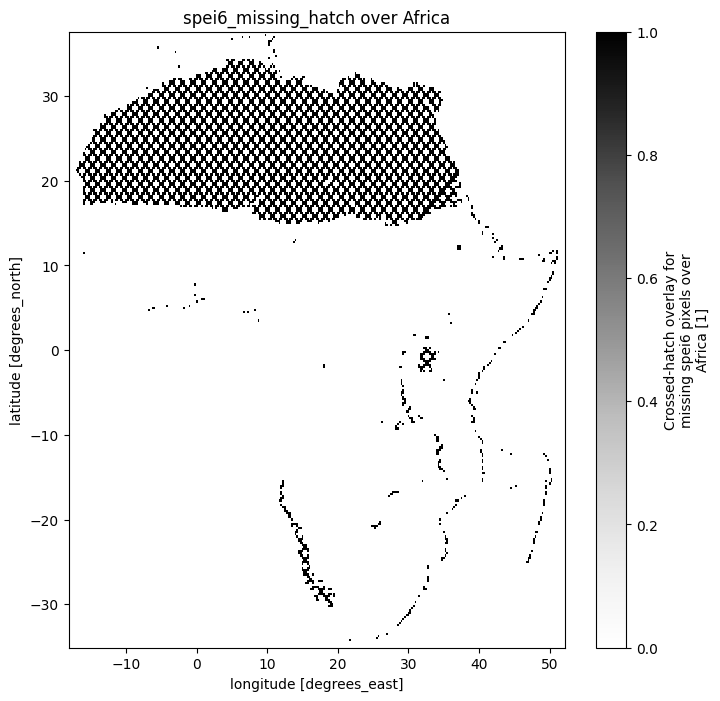

In [6]:
hatch_da.plot(figsize=(8, 8), cmap="Greys", vmin=0, vmax=1)

plt.title(f"{hatch_name} over Africa")
plt.show()


## Save the final crossed-hatch overlay NetCDF

This keeps a lightweight raster overlay layer with crossed hatch pixels valued at 1 and NaN elsewhere.

In [7]:
bounds_vars = [name for name in ds_hatch.variables if "bnds" in name.lower() or name.lower().endswith("_bounds")]
ds_hatch_clean = ds_hatch.drop_vars(bounds_vars, errors="ignore")
output_path = dest / "era5_africa_drought_missing_hatch.nc"

if output_path.exists():
    output_path.unlink()

ds.close()
 
output_path = dest / "era5_africa_drought_missing_hatch.nc"
encoding = {
    name: {"zlib": True, "complevel": 1}
    for name in ds_hatch_clean.data_vars
}

ds_hatch_clean.to_netcdf(output_path, encoding=encoding)
print("Saved:", output_path)


Saved: /home/abdessamadelh/Documents/stage/Tests/c3s-atlas-main/book/customizing/data/africa_era5_drought/era5_africa_drought_missing_hatch.nc
